In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

In [3]:
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')

In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


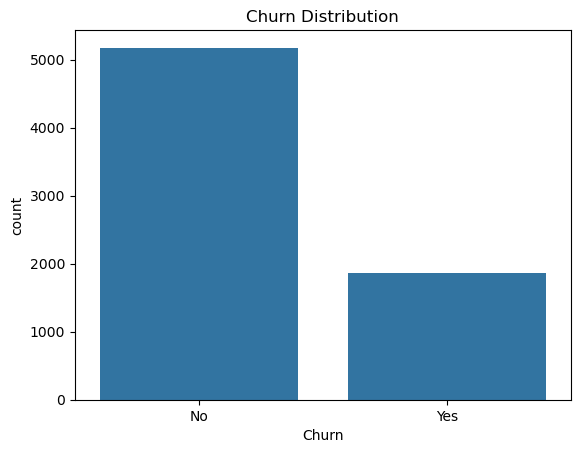

In [10]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.savefig('churn_dist.png')

print(df['Churn'].value_counts(normalize=True))

<Axes: title={'center': 'Churn rate by contact'}, xlabel='Contract', ylabel='Count'>

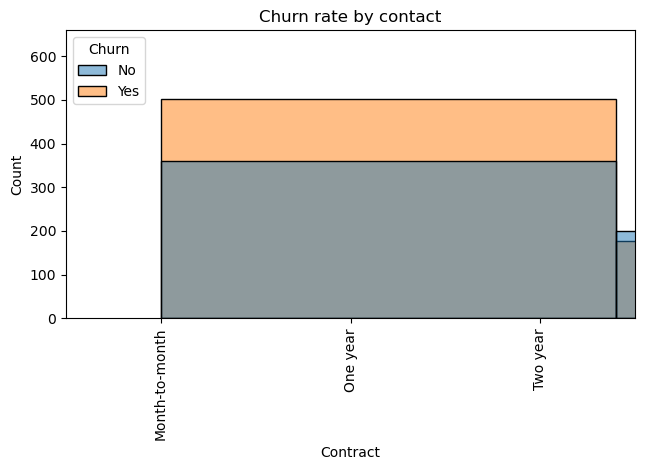

In [11]:
# Churn rate bu contact type
df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()).plot(kind='bar',
                                                                        title='Churn rate by contact')
plt.tight_layout()
plt.savefig('churn_by_contract.png')

# Tenure distribution
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)

In [12]:
# Encode churn for correlation
df_num = df.copy()
df_num['Churn_bin'] = (df_num['Churn'] == 'Yes').astype(int)

corr = df_num.select_dtypes(include='number').corr()['Churn_bin'].sort_values()
print(corr)

tenure           -0.352229
TotalCharges     -0.199484
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Churn_bin         1.000000
Name: Churn_bin, dtype: float64


In [13]:
# Handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna({'TotalCharges': df['TotalCharges'].median()}, inplace=True)
df.drop('customerID', axis=1, inplace=True)

In [14]:
# charges per month (value ratio)
df['charges_per_tenure'] = df['TotalCharges']/(df['tenure'] + 1)

# High-value customer flag
df['is_high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)).astype(int)

# Service count (how many services does customer use?)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df['service_count'] = (df[service_cols] == 'Yes').sum(axis=1)

In [15]:
# Encode categorical method
from sklearn.preprocessing import LabelEncoder

# Binary encode Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'gender']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-hot encode multi-category columns
df = pd.get_dummies(df, columns=['MultipleLines', 'InternetService', 'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies',
    'Contract','PaymentMethod'], drop_first=True)

In [16]:
# Split data and scale features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train) # fit Only on train
X_test_sc = scaler.transform(X_test) # transform test

In [17]:
# Train Baseline XGboost model
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=3, #handles class imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

[0]	validation_0-logloss:0.67942
[50]	validation_0-logloss:0.49807


C:\Users\akku8\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:03:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-logloss:0.49400
[150]	validation_0-logloss:0.49436
[199]	validation_0-logloss:0.49360


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.8364


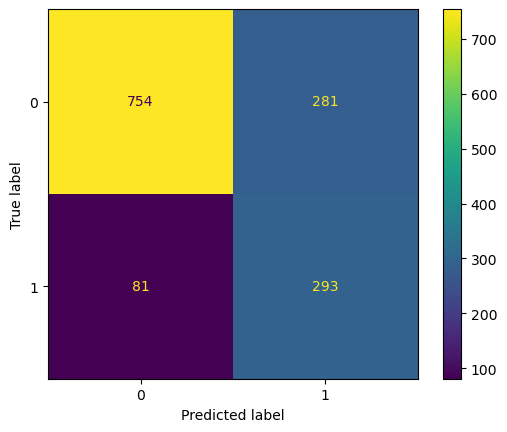

In [18]:
# Evaluate with the RIGHT metrics
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.savefig("confusion_matrix.png")

In [19]:
# Tune with cross-validation
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.1]
}

rs = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=3, random_state=42),
    param_distributions=param_dist,
    n_iter=20, cv=5, scoring='roc_auc',
    n_jobs=-1, random_state=42
)

rs.fit(X_train, y_train)
print(rs.best_params_)
best_model = rs.best_estimator_

{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [20]:
# Adjust decision threshold
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.3, 0.7, 0.05)
best_thresh, best_f1 = 0.5, 0
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f"Best threshold: {best_thresh:.2f}, F1: {best_f1:.4f}")
y_pred_final = (y_prob >= best_thresh).astype(int)

Best threshold: 0.55, F1: 0.6312


In [21]:
# Compute SHAP value
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("(one row per prediction, one col per feature)")

SHAP values shape: (1409, 33)
(one row per prediction, one col per feature)


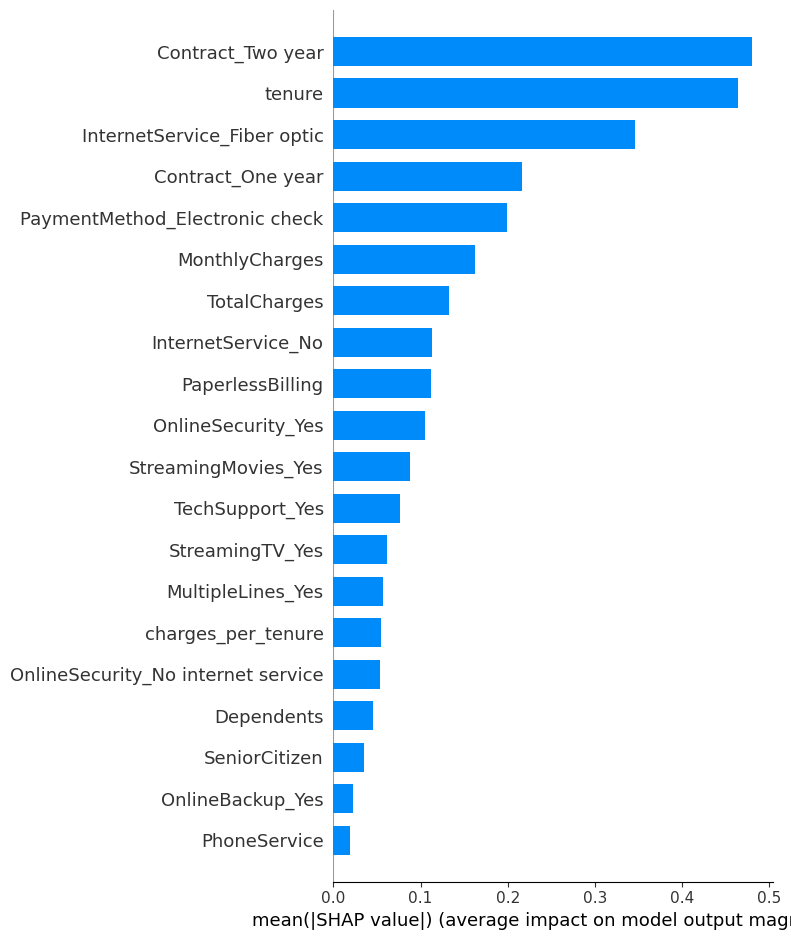

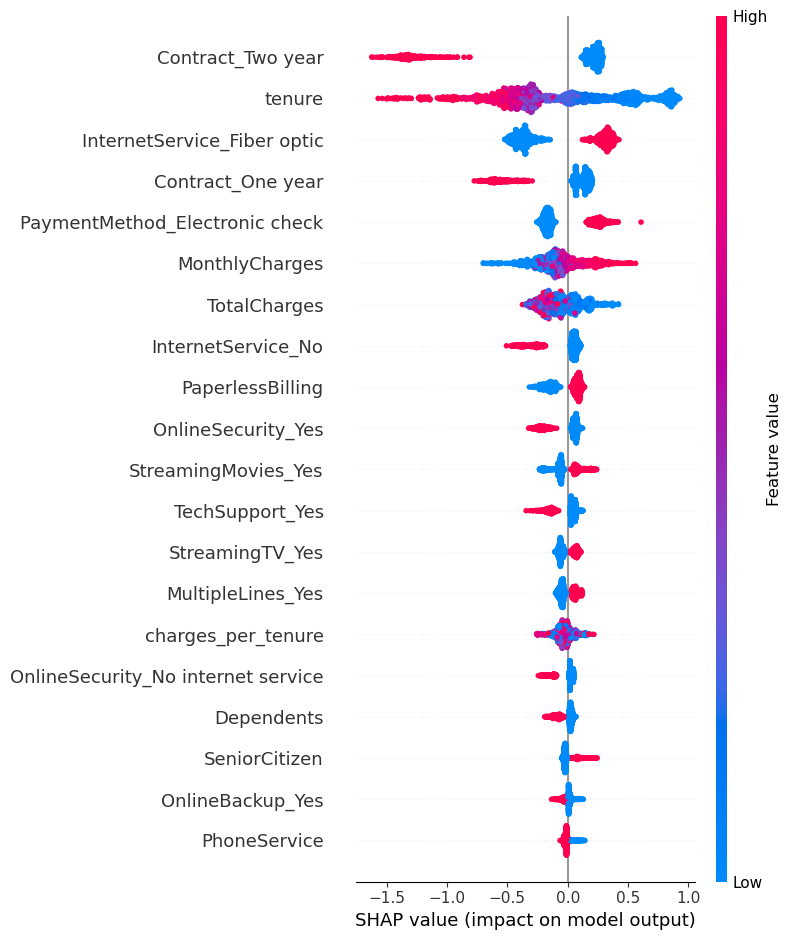

<Figure size 640x480 with 0 Axes>

In [22]:
# Global feature importance plot (shows which feature matter most across ALL customers.)

shap.summary_plot(shap_values, X_test, plot_type='bar')
plt.savefig('shap_importance.png', bbox_inches='tight')

shap.summary_plot(shap_values, X_test) # beeswarm
plt.savefig('shap_beeswarm.png', bbox_inches='tight')

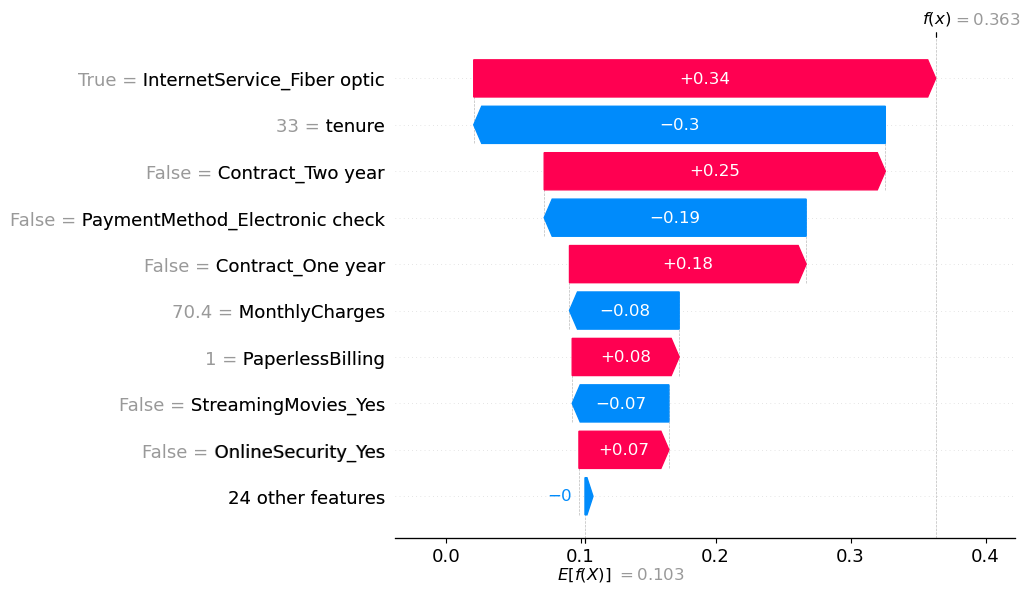

<Figure size 640x480 with 0 Axes>

In [23]:
# Individual prediction explaination
# Explain prediction for customer at index 42

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[42],
        base_values=explainer.expected_value,
        data=X_test.iloc[42],
        feature_names=X_test.columns.tolist()
    )
)
plt.savefig('waterfall_customer42.png', bbox_inches='tight')

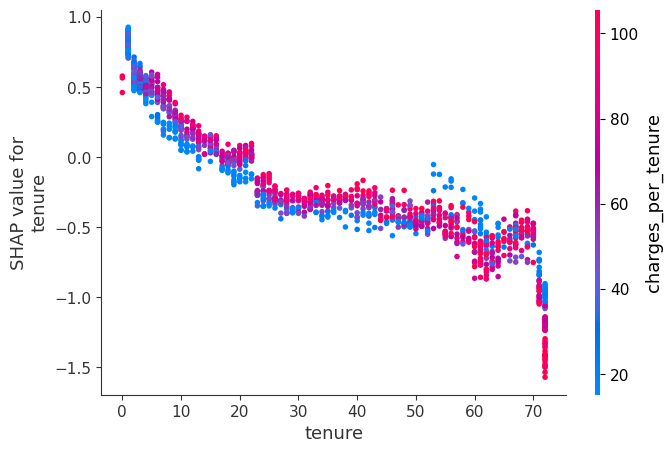

<Figure size 640x480 with 0 Axes>

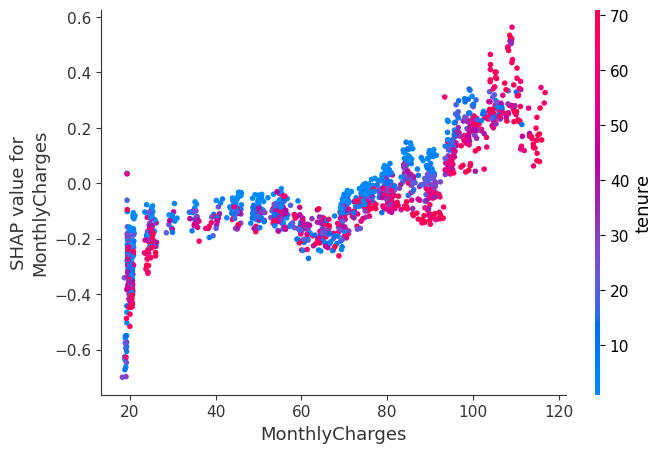

In [24]:
# SHAP dependence plot

# How does tenure affect churn predictions?
shap.dependence_plot('tenure', shap_values, X_test)
plt.savefig('shap_tenure_dependence.png', bbox_inches='tight')

# For MonthlyCharges
shap.dependence_plot('MonthlyCharges', shap_values, X_test)

In [25]:
import joblib
import os

joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')

# Verify files saved correctly
for f in ['model.pkl', 'scaler.pkl', 'feature_names.pkl']:
    print(f"{f} saved - size: {os.path.getsize(f):,} bytes")

model.pkl saved - size: 169,573 bytes
scaler.pkl saved - size: 2,575 bytes
feature_names.pkl saved - size: 776 bytes
